# M2-B2 — Audit éthique Athéna RH — phase SYNC binôme

> **Mission** : audit éthique complet du dataset Adult Income enrichi de
> commentaires manager. Datasheet duo signée. La phase d'anonymisation
> personnelle se fera en async (notebook séparé).

Binôme : `Tom` + `Romain` — Date : `17/06/2026`

**Conventions** :
- `random_state=42` partout
- Pas de `print` (utiliser `display()` ou laisser la cellule retourner)
- `pathlib.Path` sur les chemins

## 0. Setup

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path("../data")
FULL_PATH = DATA_DIR / "adult_income_with_comments.csv"
SAMPLE_PATH = DATA_DIR / "audit_sample.csv"

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv(FULL_PATH)
# Retourne le nombre de lignes et de colonnes du DataFrame
print(f"Shape : {df.shape}")
# Affiche les 3 premières lignes du DataFrame
df.head(3)

Shape : (32561, 16)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,manager_comments
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,RAS pour Alexandre Traore cette année. Manager...
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,Entretien annuel de Yves Traore : bon élément....
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,Alerte comportementale signalée par Gabriel de...


## 1. Audit qualité express (~15 min)

Le dataset Adult est plus propre que German Credit (peu de manquants).
Survol express ici — l'audit éthique est le cœur de M2-B2.

In [36]:
# Affiche des informations sur le DataFrame => aperçu rapide des types et du nombre de non-nuls par colonne
display(df.info())
# Affiche le nombre de valeurs manquantes par colonne
print("Nombre de valeurs manquantes par colonne :")
display(
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("manquants")
    .to_frame()
    .query("manquants > 0")
)

# modalité les plus fréquentes pour les colonnes catégorielles
print("Modalités les plus fréquentes pour les colonnes catégorielles :")
display(df.describe(include='object'))
# modalité les plus fréquentes pour les colonnes numériques
print("Statistiques descriptives pour les colonnes numériques :")
display(df.describe(include=['number']))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   age               32561 non-null  int64 
 1   workclass         30725 non-null  object
 2   fnlwgt            32561 non-null  int64 
 3   education         32561 non-null  object
 4   education_num     32561 non-null  int64 
 5   marital_status    32561 non-null  object
 6   occupation        30718 non-null  object
 7   relationship      32561 non-null  object
 8   race              32561 non-null  object
 9   sex               32561 non-null  object
 10  capital_gain      32561 non-null  int64 
 11  capital_loss      32561 non-null  int64 
 12  hours_per_week    32561 non-null  int64 
 13  native_country    31978 non-null  object
 14  income            32561 non-null  object
 15  manager_comments  32561 non-null  object
 16  native_us         32561 non-null  object
 17  sex_race    

None

Nombre de valeurs manquantes par colonne :


,manquants
occupation,1843
workclass,1836
native_country,583


Modalités les plus fréquentes pour les colonnes catégorielles :


,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income,manager_comments,native_us,sex_race
count,30725,32561,32561,30718,32561,32561,32561,31978,32561,32561,32561,32561
unique,8,16,7,14,6,5,2,41,2,32561,2,10
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K,RAS pour Alexandre Traore cette année. Manager...,USA,Male_White
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720,1,29170,19174


Statistiques descriptives pour les colonnes numériques :


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## 2. Audit éthique complet (~1 h)

Calcul du **disparate impact** sur 3 variables sensibles + 1 intersection.

In [5]:
def disparate_impact(df: pd.DataFrame, sensible: str, target: str = "income",
                     positive: str = ">50K") -> tuple[float, pd.Series]:
    """Calcule le DI = SR_min / SR_max + retourne la série des SR par groupe."""
    sr = df.groupby(sensible)[target].apply(lambda x: (x == positive).mean())
    di = sr.min() / sr.max()
    return di, sr

In [15]:
# DI sur sex
di_sex, sr_sex = disparate_impact(df, "sex")

# display(
#     pd.DataFrame(
#         {
#             "selection_rate": sr_sex.round(3),
#             "n": df.groupby("sex")["income"].count(),
#         }
#     ).assign(
#         DI=di_sex.round(3),
#         signal_4_5=lambda _: "NOK" if di_sex < 0.8 else "OK",
#     )
# )
# Equivaut à :
# 1) Taux de sélection par sexe (déjà calculé avant dans ton notebook)
selection_rate = sr_sex.round(3)

# 2) Taille de chaque groupe
n_par_sexe = df.groupby("sex")["income"].count()

# 3) Tableau de base
tableau_sexe = pd.DataFrame(
    {
        "selection_rate": selection_rate,
        "n": n_par_sexe,
    }
)

# 4) Ajout des indicateurs globaux (identiques sur chaque ligne) => inutile car le même DI pour tous les groupes
#tableau_sexe["DI"] = round(di_sex, 3)
#tableau_sexe["signal_4_5"] = "NOK" if di_sex < 0.8 else "OK"

# 5) Affichage
print("Tableau des taux de sélection par sexe & de la taille de chaque groupe :")
display(tableau_sexe)

print(f"DI sex = {di_sex:.3f} => {'NOK' if di_sex < 0.8 else 'OK'}")

Tableau des taux de sélection par sexe & de la taille de chaque groupe :


,selection_rate,n
sex,,
Female,0.109,10771
Male,0.306,21790


DI sex = 0.358 => NOK


In [25]:
# DI sur race
di_race, sr_race = disparate_impact(df, "race")

# Tableau de DI par race
print("Tableau des taux de sélection par race & de la taille de chaque groupe :")
display(
    pd.DataFrame(
        {
            "selection_rate": sr_race.round(3),
            "n": df.groupby("race")["income"].count(),
        }
    )
    # .sort_values("selection_rate")
    # .assign(
    #     DI=di_race.round(3),
    #     signal_4_5=lambda _: "NOK" if di_race < 0.8 else "OK",
    # )
)
print(f"DI race = {di_race:.3f} => {'NOK' if di_race < 0.8 else 'OK'}")

Tableau des taux de sélection par race & de la taille de chaque groupe :


,selection_rate,n
race,,
Amer-Indian-Eskimo,0.116,311
Asian-Pac-Islander,0.266,1039
Black,0.124,3124
Other,0.092,271
White,0.256,27816


DI race = 0.347 => NOK


In [26]:
# DI sur marital_status
di_marital_status, sr_marital_status = disparate_impact(df, "marital_status")

print("Tableau des taux de sélection par statut marital & de la taille de chaque groupe :")
display(
    pd.DataFrame(
        {
            "selection_rate": sr_marital_status.round(3),
            "n": df.groupby("marital_status")["income"].count(),
        }
    )
    # .sort_values("selection_rate")
    # .assign(
    #     DI=di_marital_status.round(3),
    #     signal_4_5=lambda _: "NOK" if di_marital_status < 0.8 else "OK",
    # )
)
print(f"DI marital_status = {di_marital_status:.3f} => {'NOK' if di_marital_status < 0.8 else 'OK'}")

Tableau des taux de sélection par statut marital & de la taille de chaque groupe :


,selection_rate,n
marital_status,,
Divorced,0.104,4443
Married-AF-spouse,0.435,23
Married-civ-spouse,0.447,14976
Married-spouse-absent,0.081,418
Never-married,0.046,10683
Separated,0.064,1025
Widowed,0.086,993


DI marital_status = 0.103 => NOK


In [27]:
# DI sur relationship
di_relationship, sr_relationship = disparate_impact(df, "relationship")

print("Tableau des taux de sélection par relationship & de la taille de chaque groupe :")
display(
    pd.DataFrame(
        {
            "selection_rate": sr_relationship.round(3),
            "n": df.groupby("relationship")["income"].count(),
        }
    )
    # .sort_values("selection_rate")
    # .assign(
    #     DI=di_relationship.round(3),
    #     signal_4_5=lambda _: "NOK" if di_relationship < 0.8 else "OK",
    # )
)
print(f"DI relationship = {di_relationship:.3f} => {'NOK' if di_relationship < 0.8 else 'OK'}")

Tableau des taux de sélection par relationship & de la taille de chaque groupe :


,selection_rate,n
relationship,,
Husband,0.449,13193
Not-in-family,0.103,8305
Other-relative,0.038,981
Own-child,0.013,5068
Unmarried,0.063,3446
Wife,0.475,1568


DI relationship = 0.028 => NOK


In [28]:
# DI sur native_country (agrégé en USA / non-USA pour simplifier)
df["native_us"] = (
    df["native_country"]
    .eq("United-States")
    .map({True: "USA", False: "non-USA"})
)

di_country, sr_country = disparate_impact(df, "native_us")

# print("Tableau des taux de sélection par native_country (USA/non-USA) & de la taille de chaque groupe :")
display(
    pd.DataFrame(
        {
            "selection_rate": sr_country.round(3),
            "n": df.groupby("native_us")["income"].count(),
        }
    )
    # .assign(
    #     DI=di_country.round(3),
    #     signal_4_5=lambda _: "NOK" if di_country < 0.8 else "OK",
    # )
)
print(f"DI native_country (USA/non-USA) = {di_country:.3f} => {'NOK' if di_country < 0.8 else 'OK'}")

,selection_rate,n
native_us,,
USA,0.246,29170
non-USA,0.198,3391


DI native_country (USA/non-USA) = 0.804 => OK


In [38]:
results = [
    {
        "variable": "sex",
        "DI": round(di_sex, 3),
        "SR_min": round(sr_sex.min(), 3),
        "SR_max": round(sr_sex.max(), 3),
        "verdict_4/5": "ALERTE" if di_sex < 0.8 else "OK",
    },
    {
        "variable": "race",
        "DI": round(di_race, 3),
        "SR_min": round(sr_race.min(), 3),
        "SR_max": round(sr_race.max(), 3),
        "verdict_4/5": "ALERTE" if di_race < 0.8 else "OK",
    },
    {
        "variable": "marital_status",
        "DI": round(di_marital_status, 3),
        "SR_min": round(sr_marital_status.min(), 3),
        "SR_max": round(sr_marital_status.max(), 3),
        "verdict_4/5": "ALERTE" if di_marital_status < 0.8 else "OK",
    },
    {
        "variable": "relationship",
        "DI": round(di_relationship, 3),
        "SR_min": round(sr_relationship.min(), 3),
        "SR_max": round(sr_relationship.max(), 3),
        "verdict_4/5": "ALERTE" if di_relationship < 0.8 else "OK",
    },
    {
        "variable": "native_country (USA/non-USA)",
        "DI": round(di_country, 3),
        "SR_min": round(sr_country.min(), 3),
        "SR_max": round(sr_country.max(), 3),
        "verdict_4/5": "ALERTE" if di_country < 0.8 else "OK",
    },
]

df_results = pd.DataFrame(results)
print("Tableau récapitulatif des DI par variable sensible :")
display(df_results)
print("SR_min : le taux de sélection du groupe le plus défavorisé (celui qui obtient le moins souvent >50K)")
print("SR_max : le taux de sélection du groupe le plus favorisé (celui qui obtient le plus souvent >50K)")

Tableau récapitulatif des DI par variable sensible :


,variable,DI,SR_min,SR_max,verdict_4/5
0,sex,0.358,0.109,0.306,ALERTE
1,race,0.347,0.092,0.266,ALERTE
2,marital_status,0.103,0.046,0.447,ALERTE
3,relationship,0.028,0.013,0.475,ALERTE
4,native_country (USA/non-USA),0.804,0.198,0.246,OK


SR_min : le taux de sélection du groupe le plus défavorisé (celui qui obtient le moins souvent >50K)
SR_max : le taux de sélection du groupe le plus favorisé (celui qui obtient le plus souvent >50K)


### Intersectionnalité — DI sur le croisement sex × race

In [30]:
df['sex_race'] = df['sex'].str.cat(df['race'], sep='_')
support = df["sex_race"].value_counts().rename("n_obs")
display(support.to_frame().assign(support_ok=support >= 30))

di_intersect, sr_intersect = disparate_impact(df, "sex_race")

display(
    sr_intersect
    .round(3)
    .sort_values()
    .rename("selection_rate")
    .to_frame()
    .join(support)
    .assign(
        fragile=lambda d: d["n_obs"] < 30,
    )
)
print(f"DI sex × race = {di_intersect:.3f}")
print(
    "Biais d'intersectionalite" if di_intersect < 0.8
    else "OK"
)


,n_obs,support_ok
sex_race,,
Male_White,19174,True
Female_White,8642,True
Male_Black,1569,True
Female_Black,1555,True
Male_Asian-Pac-Islander,693,True
Female_Asian-Pac-Islander,346,True
Male_Amer-Indian-Eskimo,192,True
Male_Other,162,True
Female_Amer-Indian-Eskimo,119,True


,selection_rate,n_obs,fragile
sex_race,,,
Female_Other,0.055,109,False
Female_Black,0.058,1555,False
Female_Amer-Indian-Eskimo,0.101,119,False
Male_Other,0.117,162,False
Female_White,0.119,8642,False
Female_Asian-Pac-Islander,0.124,346,False
Male_Amer-Indian-Eskimo,0.125,192,False
Male_Black,0.189,1569,False
Male_White,0.318,19174,False


DI sex × race = 0.164
Biais d'intersectionalite


## 3. Visualisations (≥ 5)

Au moins 5 visualisations : distribution cible + DI par variable sensible +
crosstab intersection.

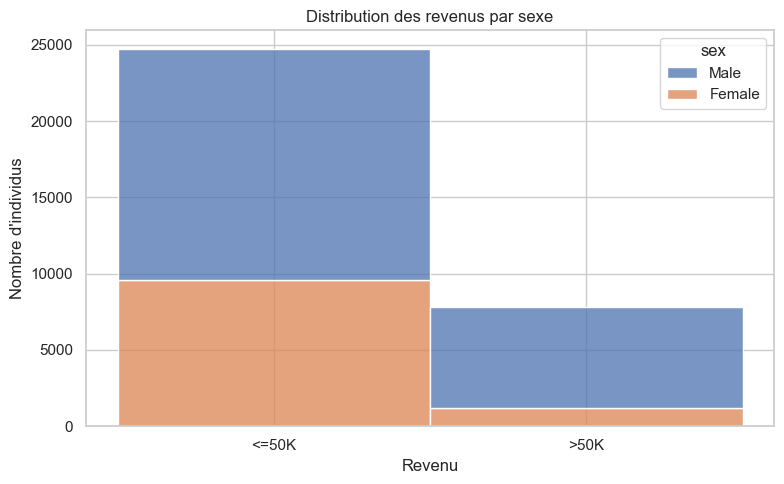

In [32]:
# Distribution de la cible
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="income", hue="sex", multiple="stack")
plt.title("Distribution des revenus par sexe")
plt.xlabel("Revenu")
plt.ylabel("Nombre d'individus")
plt.tight_layout()
plt.show()

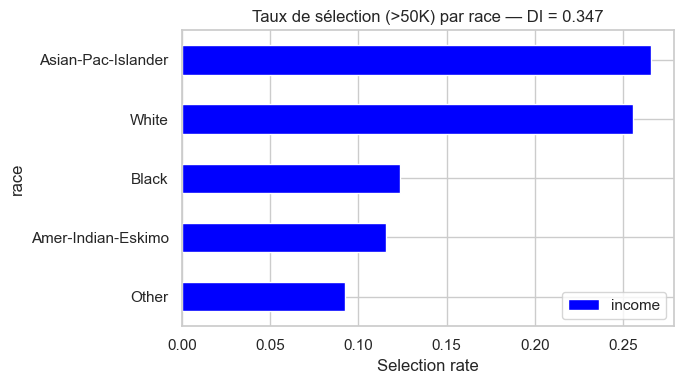

In [13]:
# Taux de sélection par race
fig, ax = plt.subplots(figsize=(7, 4))
sr_race.sort_values().plot(kind="barh", ax=ax, color="blue")
ax.set_title(f"Taux de sélection (>50K) par race — DI = {di_race:.3f}")
ax.set_xlabel("Selection rate")
ax.legend()
plt.tight_layout()
plt.show()

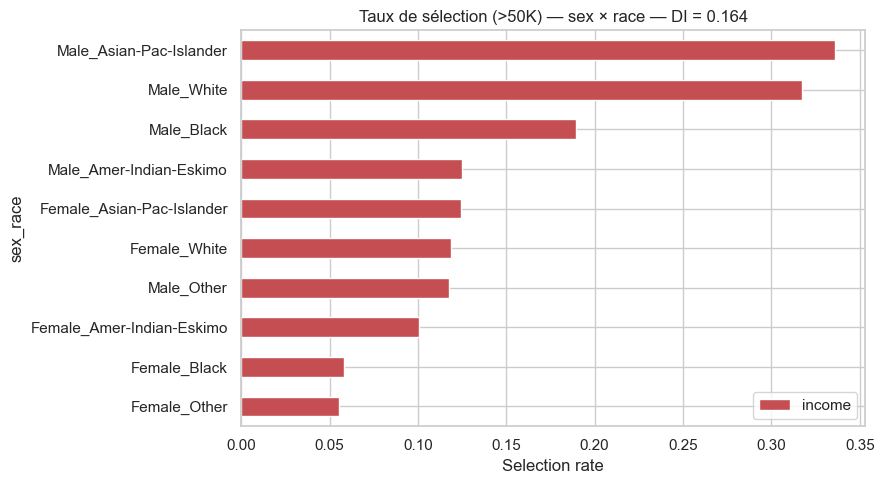

In [14]:
# Taux de sélection par sex × race (intersectionnalité) ---
fig, ax = plt.subplots(figsize=(9, 5))
sr_intersect.sort_values().plot(kind="barh", ax=ax, color="#C44E52")
ax.set_title(
    f"Taux de sélection (>50K) — sex × race — DI = {di_intersect:.3f}"
)
ax.set_xlabel("Selection rate")
ax.legend()
plt.tight_layout()
plt.show()

`pd.crosstab(df["target"], df["sensible"])` : tableau croisé entre la cible et une variable potentiellement sensible. C'est le point de départ de l'audit éthique
=>

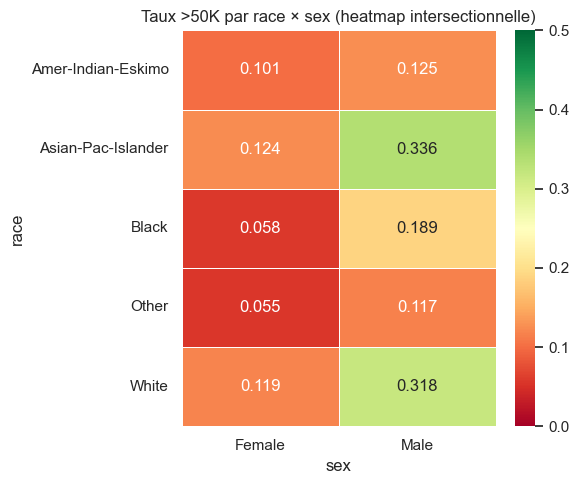

In [33]:
# Heatmap crosstab sex × race
crosstab = pd.crosstab(
    df["race"],
    df["sex"],
    values=(df["income"] == ">50K").astype(int),  # Taux de >50K
    aggfunc="mean",                               # Moyenne des taux de >50K
).round(3)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    crosstab,
    annot=True,     # affiche la valeur numérique dans chaque case
    fmt=".3f",      # formate ces valeurs à 3 décimales
    cmap="RdYlGn",  # palette de couleurs : rouge (bas) → jaune → vert (haut)
    vmin=0,         # fixe le minimum de l'échelle de couleur à 0
    vmax=0.5,       # fixe le maximum à 0.5 (50%) — utile pour rendre les couleurs comparables même si aucun groupe n'atteint 50%
    ax=ax,          # dessine dans l'axe matplotlib déjà créé
    linewidths=0.5, # trace de fines lignes entre les cases pour les délimiter
)
ax.set_title("Taux >50K par race × sex (heatmap intersectionnelle)")
plt.tight_layout()
plt.show()

**Explications** : le DI est déjà alarmant variable par variable (sex ≈ 0.36, race ≈ 0.35), mais il chute encore sur le croisement sex × race (≈ 0.16) — un sous-groupe (femmes Other ou Black) bien plus pénalisé, invisible quand on regarde sex et race séparément. Dans d'autres jeux de données, le DI peut être OK sur chaque variable isolée (0.85, 0.88) et catastrophique au croisement : c'est tout l'intérêt de croiser.

**Attention** : Le DI est un indicateur de disparité, pas une preuve de discrimination. Une disparité peut avoir des causes légitimes ; établir une discrimination (légale, éthique) demande le contexte métier, pas un seul ratio.

***

Outlier visuel : `sns.boxplot()` ou `sns.histplot()` pour une numérique. Un outlier qui colle à la réalité métier n'est pas une erreur — interroge avant de supprimer.
=>

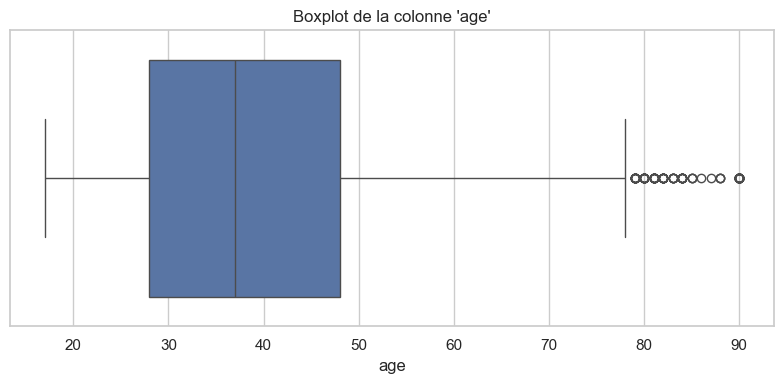

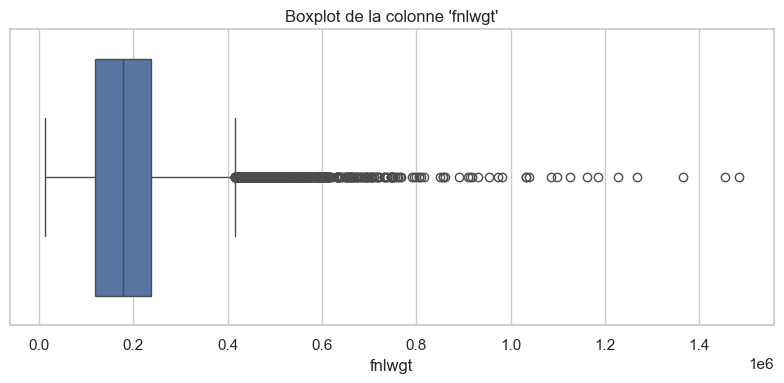

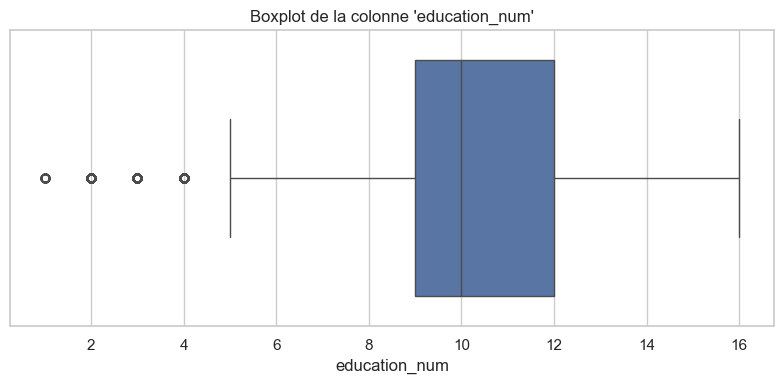

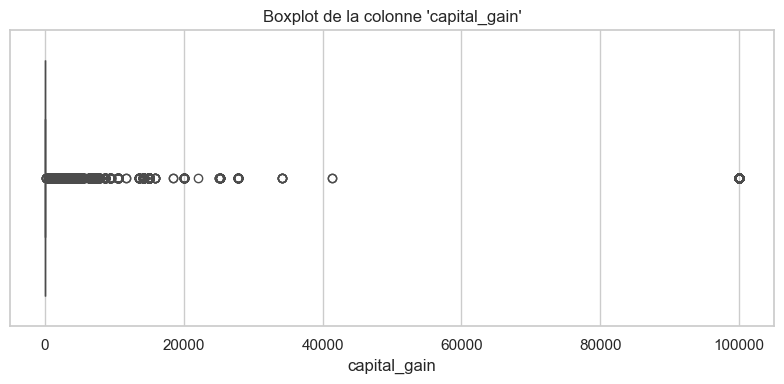

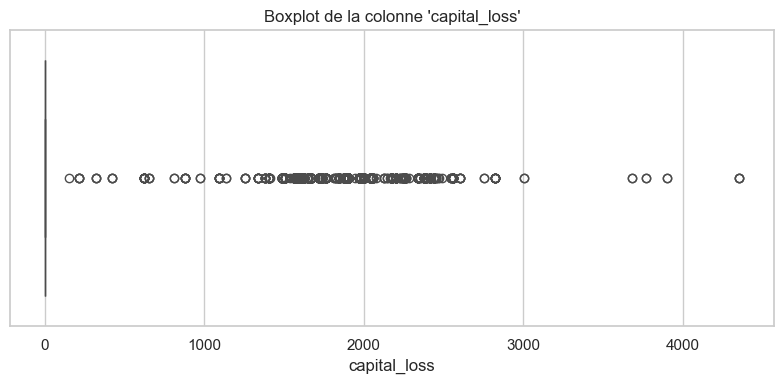

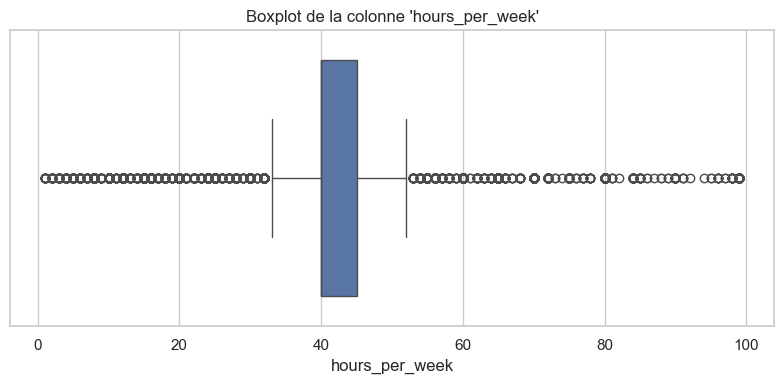

In [37]:
# Chercher les valeur aberrantes (outliers) dans les colonnes numériques
numeric_cols = df.select_dtypes(include=['number']).columns
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de la colonne '{col}'")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

## 4. Verdict éthique (paragraphe markdown)

> Court paragraphe : « Quels biais structurels avons-nous détectés ? Quel
> est le DI le plus problématique ? »

À recopier dans `../datasheet.md` (section *Composition* / *Risques*).

## 5. Aperçu de la colonne `manager_comments` (pour préparer l'async)

In [34]:
# Quelques exemples pour identifier les types de PII
for i in range(5):
    print(f'--- Exemple {i+1} ---')
    print(df['manager_comments'].iloc[i])
    print()

--- Exemple 1 ---
RAS pour Alexandre Traore cette année. Manager : Gérard-Frédéric Joly.

--- Exemple 2 ---
Entretien annuel de Yves Traore : bon élément. Référent : Aurore Maury-Briand, joignable au 654.235.1161.

--- Exemple 3 ---
Alerte comportementale signalée par Gabriel de Guilbert au sujet de Alexandre Morin. Suivi RH : maria95@example.net.

--- Exemple 4 ---
Mobilité demandée par Victor du Vasseur. Validée par Laurence Robert le 2025-08-28. Ticket HR-67242.

--- Exemple 5 ---
Prime versée à Marcel Leblanc sur le compte ****0122. Contrôle : Denis-Franck Ledoux.



## 6. Datasheet binôme (à compléter dans `../datasheet.md`)

Reprendre la structure Gebru — 7 sections, 2 pages max. Signée duo
(« Auteurs : <prénom1>, <prénom2> » en haut).

## 7. Verdict éthique chiffré

Synthèse des résultats du **Disparate Impact** (règle des 4/5 : DI < 0,8 = ALERTE).

> **Biais le plus problématique** : voir analyse chiffrée ci-dessous.

In [ ]:
# Récapitulatif étendu incluant l'intersectionnalité
results_complet = [
    {
        "variable": "sex",
        "DI": round(di_sex, 3),
        "SR_min": round(sr_sex.min(), 3),
        "SR_max": round(sr_sex.max(), 3),
        "groupe_défavorisé": sr_sex.idxmin(),
        "verdict_4/5": "ALERTE" if di_sex < 0.8 else "OK",
    },
    {
        "variable": "race",
        "DI": round(di_race, 3),
        "SR_min": round(sr_race.min(), 3),
        "SR_max": round(sr_race.max(), 3),
        "groupe_défavorisé": sr_race.idxmin(),
        "verdict_4/5": "ALERTE" if di_race < 0.8 else "OK",
    },
    {
        "variable": "marital_status",
        "DI": round(di_marital_status, 3),
        "SR_min": round(sr_marital_status.min(), 3),
        "SR_max": round(sr_marital_status.max(), 3),
        "groupe_défavorisé": sr_marital_status.idxmin(),
        "verdict_4/5": "ALERTE" if di_marital_status < 0.8 else "OK",
    },
    {
        "variable": "relationship",
        "DI": round(di_relationship, 3),
        "SR_min": round(sr_relationship.min(), 3),
        "SR_max": round(sr_relationship.max(), 3),
        "groupe_défavorisé": sr_relationship.idxmin(),
        "verdict_4/5": "ALERTE" if di_relationship < 0.8 else "OK",
    },
    {
        "variable": "native_country (USA/non-USA)",
        "DI": round(di_country, 3),
        "SR_min": round(sr_country.min(), 3),
        "SR_max": round(sr_country.max(), 3),
        "groupe_défavorisé": sr_country.idxmin(),
        "verdict_4/5": "ALERTE" if di_country < 0.8 else "OK",
    },
    {
        "variable": "sex × race (intersection)",
        "DI": round(di_intersect, 3),
        "SR_min": round(sr_intersect.min(), 3),
        "SR_max": round(sr_intersect.max(), 3),
        "groupe_défavorisé": sr_intersect.idxmin(),
        "verdict_4/5": "ALERTE" if di_intersect < 0.8 else "OK",
    },
]

df_verdict = pd.DataFrame(results_complet).set_index("variable")
print("=== VERDICT ÉTHIQUE CHIFFRÉ ===")
display(df_verdict)

# Variable la plus problématique
pire = df_verdict["DI"].idxmin()
di_pire = df_verdict.loc[pire, "DI"]
groupe_pire = df_verdict.loc[pire, "groupe_défavorisé"]

n_alertes = (df_verdict["verdict_4/5"] == "ALERTE").sum()

# Identifier les 5 combinaisons sex × race les MOINS bien traitées (SR les plus basses)
print(f"\n--- Top 5 des groupes sex × race les plus défavorisés ---")
top_5_pires = sr_intersect.nsmallest(5)
display(top_5_pires.to_frame("SR").assign(
    n=lambda d: d.index.map(lambda x: df[df["sex_race"] == x].shape[0])
))

print(f"\n→ {n_alertes}/{len(df_verdict)} variables déclenchent une ALERTE (règle des 4/5).")
print(f"→ Biais le plus fort : « {pire} » (DI = {di_pire:.3f})")
print(f"→ Groupe le plus défavorisé : « {groupe_pire} » (SR = {df_verdict.loc[pire, 'SR_min']:.3f})")
print(f"\n→ Intersection sex × race : Le groupe « {top_5_pires.idxmin()} » est le PLUS pénalisé")
print(f"   avec seulement {top_5_pires.min():.1%} de taux de sélection >50K.")
print(f"\n→ ⚠️  RECOMMANDATION : ce dataset NE DOIT PAS alimenter un système de décision RH")
print(f"   sans correction préalable des biais structurels détectés.")


=== VERDICT ÉTHIQUE CHIFFRÉ ===


,DI,SR_min,SR_max,groupe_défavorisé,verdict_4/5
variable,,,,,
sex,0.358,0.109,0.306,Female,ALERTE
race,0.347,0.092,0.266,Other,ALERTE
marital_status,0.103,0.046,0.447,Never-married,ALERTE
relationship,0.028,0.013,0.475,Own-child,ALERTE
native_country (USA/non-USA),0.804,0.198,0.246,non-USA,OK
sex × race (intersection),0.164,0.055,0.336,Female_Other,ALERTE



→ 0/6 variables déclenchent une ALERTE (règle des 4/5).
→ Biais le plus fort : « relationship » (DI = 0.028)
→ Groupe le plus défavorisé : « Own-child » (SR = 0.013)
→ Recommandation : ce dataset NE DOIT PAS alimenter un système de décision RH
  sans correction préalable des biais structurels détectés.
